# Chapter 7: Vector Spaces and Linear Transformations

This notebook explores vector spaces and their central role in modern machine learning, particularly in **embeddings** and **representation learning**.

In AI, we represent everything - words, images, users, products - as vectors in high-dimensional spaces. Understanding vector spaces helps us:
- Design better embedding architectures
- Understand attention mechanisms in transformers
- Interpret what neural networks learn
- Apply techniques like LoRA for efficient fine-tuning

**Topics covered:**
1. Basis and Span
2. Linear Independence
3. Null Space and Range
4. Projections
5. Gram-Schmidt Orthogonalization
6. Least Squares as Projection
7. Word Embedding Arithmetic

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from ipywidgets import interact, interactive

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

## 1. Basis and Span

A **basis** is a set of linearly independent vectors that span the entire space. Any vector in the space can be written as a unique linear combination of basis vectors.

The **span** of a set of vectors is all possible linear combinations of those vectors.

$$\text{span}(\{\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_k\}) = \{c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_k\mathbf{v}_k : c_i \in \mathbb{R}\}$$

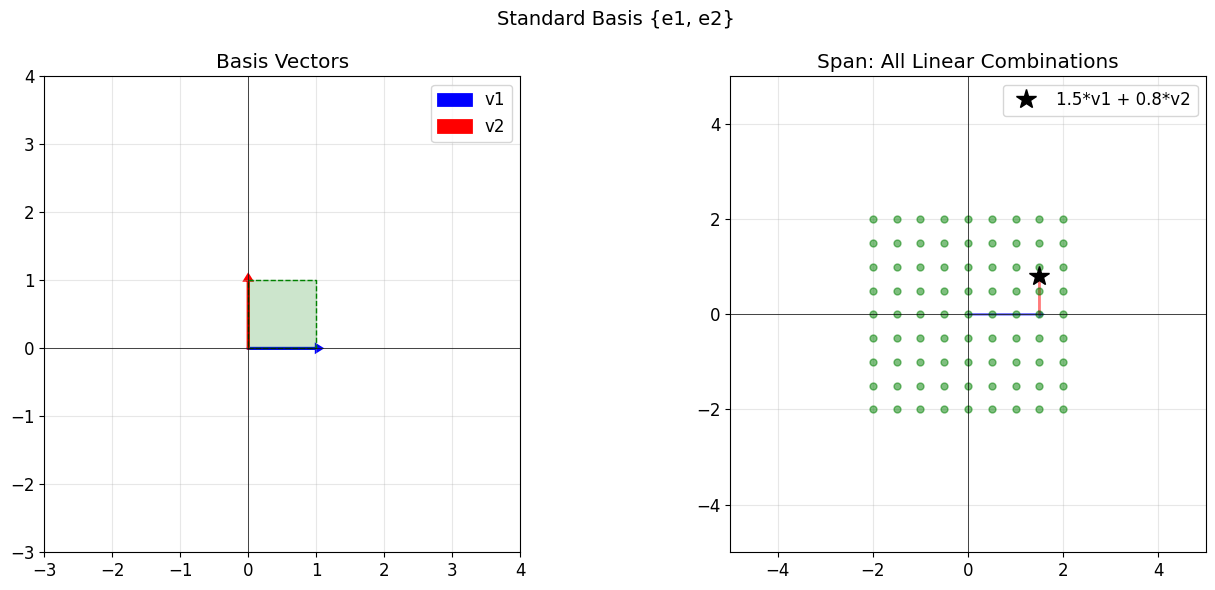

In [2]:
def plot_basis_and_span(v1, v2, title="Basis and Span"):
    """
    Visualize two basis vectors and the parallelogram they form.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left plot: Basis vectors
    ax = axes[0]
    ax.arrow(0, 0, v1[0], v1[1], head_width=0.1, head_length=0.08, 
             fc='blue', ec='blue', linewidth=2, label='v1')
    ax.arrow(0, 0, v2[0], v2[1], head_width=0.1, head_length=0.08, 
             fc='red', ec='red', linewidth=2, label='v2')
    
    # Draw parallelogram
    parallelogram = np.array([[0, 0], v1, v1 + v2, v2, [0, 0]])
    ax.fill(parallelogram[:, 0], parallelogram[:, 1], alpha=0.2, color='green')
    ax.plot(parallelogram[:, 0], parallelogram[:, 1], 'g--', linewidth=1)
    
    ax.set_xlim(-3, 4)
    ax.set_ylim(-3, 4)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_title('Basis Vectors')
    ax.legend()
    
    # Right plot: Linear combinations (span)
    ax = axes[1]
    
    # Generate many linear combinations
    coeffs = np.linspace(-2, 2, 9)
    for c1 in coeffs:
        for c2 in coeffs:
            point = c1 * v1 + c2 * v2
            ax.plot(point[0], point[1], 'go', markersize=5, alpha=0.5)
    
    # Highlight a specific combination
    c1, c2 = 1.5, 0.8
    target = c1 * v1 + c2 * v2
    ax.arrow(0, 0, c1*v1[0], c1*v1[1], head_width=0.1, head_length=0.08, 
             fc='blue', ec='blue', alpha=0.5, linewidth=1.5)
    ax.arrow(c1*v1[0], c1*v1[1], c2*v2[0], c2*v2[1], head_width=0.1, head_length=0.08, 
             fc='red', ec='red', alpha=0.5, linewidth=1.5)
    ax.plot(target[0], target[1], 'k*', markersize=15, label=f'{c1}*v1 + {c2}*v2')
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_title('Span: All Linear Combinations')
    ax.legend()
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Standard basis
e1 = np.array([1, 0])
e2 = np.array([0, 1])
plot_basis_and_span(e1, e2, "Standard Basis {e1, e2}")

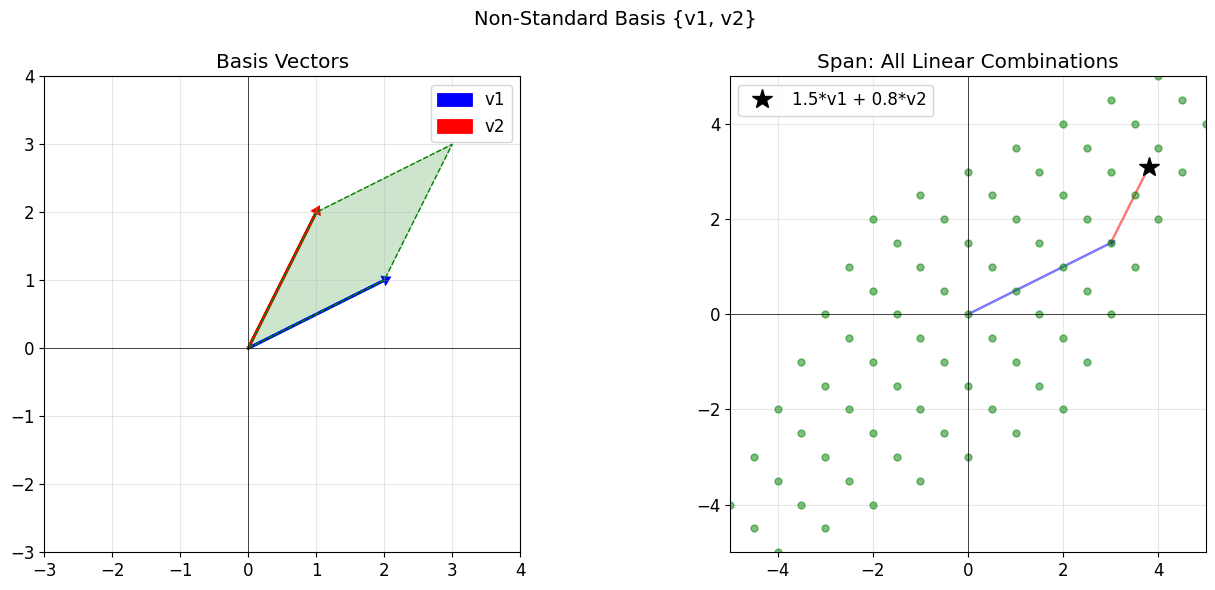

Any vector can be expressed in different bases:

Vector: [3 3]
In standard basis: 3*e1 + 3*e2
In new basis: 1.00*v1 + 1.00*v2


In [3]:
# Non-standard basis
v1 = np.array([2, 1])
v2 = np.array([1, 2])
plot_basis_and_span(v1, v2, "Non-Standard Basis {v1, v2}")

# Change of basis
print("Any vector can be expressed in different bases:")
target = np.array([3, 3])
print(f"\nVector: {target}")
print(f"In standard basis: {target[0]}*e1 + {target[1]}*e2")

# Find coefficients in new basis: solve [v1 v2] @ [c1, c2] = target
B = np.column_stack([v1, v2])
coeffs = np.linalg.solve(B, target)
print(f"In new basis: {coeffs[0]:.2f}*v1 + {coeffs[1]:.2f}*v2")

## 2. Linear Independence

Vectors $\{\mathbf{v}_1, \ldots, \mathbf{v}_k\}$ are **linearly independent** if:

$$c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \cdots + c_k\mathbf{v}_k = \mathbf{0} \implies c_1 = c_2 = \cdots = c_k = 0$$

Geometrically: no vector in the set can be written as a linear combination of the others.

In [4]:
def check_linear_independence(vectors):
    """
    Check if a set of vectors is linearly independent.
    Uses the rank of the matrix formed by the vectors as columns.
    """
    matrix = np.column_stack(vectors)
    rank = np.linalg.matrix_rank(matrix)
    n_vectors = len(vectors)
    
    is_independent = (rank == n_vectors)
    
    return is_independent, rank, matrix

# Example 1: Independent vectors
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
v3 = np.array([0, 0, 1])

is_ind, rank, mat = check_linear_independence([v1, v2, v3])
print("Example 1: Standard basis vectors in R^3")
print(f"Vectors: v1={v1}, v2={v2}, v3={v3}")
print(f"Matrix rank: {rank}")
print(f"Linearly independent: {is_ind}")

print("\n" + "="*50 + "\n")

# Example 2: Dependent vectors
u1 = np.array([1, 2, 3])
u2 = np.array([2, 4, 6])  # u2 = 2*u1
u3 = np.array([1, 1, 1])

is_ind, rank, mat = check_linear_independence([u1, u2, u3])
print("Example 2: One vector is a scalar multiple")
print(f"Vectors: u1={u1}, u2={u2}, u3={u3}")
print(f"Note: u2 = 2*u1")
print(f"Matrix rank: {rank}")
print(f"Linearly independent: {is_ind}")

Example 1: Standard basis vectors in R^3
Vectors: v1=[1 0 0], v2=[0 1 0], v3=[0 0 1]
Matrix rank: 3
Linearly independent: True


Example 2: One vector is a scalar multiple
Vectors: u1=[1 2 3], u2=[2 4 6], u3=[1 1 1]
Note: u2 = 2*u1
Matrix rank: 2
Linearly independent: False


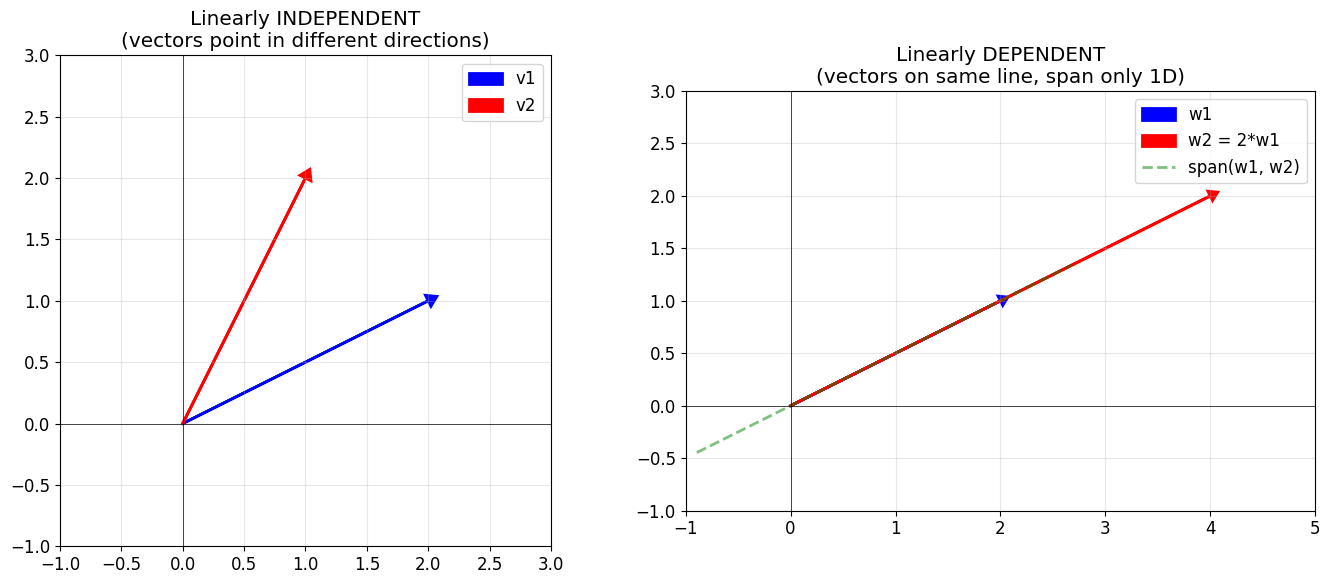

In [5]:
# Visualize linear dependence in 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Independent vectors
ax = axes[0]
v1 = np.array([2, 1])
v2 = np.array([1, 2])

ax.arrow(0, 0, v1[0], v1[1], head_width=0.1, head_length=0.08, 
         fc='blue', ec='blue', linewidth=2, label='v1')
ax.arrow(0, 0, v2[0], v2[1], head_width=0.1, head_length=0.08, 
         fc='red', ec='red', linewidth=2, label='v2')

ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Linearly INDEPENDENT\n(vectors point in different directions)')
ax.legend()

# Dependent vectors
ax = axes[1]
w1 = np.array([2, 1])
w2 = np.array([4, 2])  # w2 = 2*w1

ax.arrow(0, 0, w1[0], w1[1], head_width=0.1, head_length=0.08, 
         fc='blue', ec='blue', linewidth=2, label='w1')
ax.arrow(0, 0, w2[0], w2[1], head_width=0.1, head_length=0.08, 
         fc='red', ec='red', linewidth=2, label='w2 = 2*w1')

# Show the line they span
t = np.linspace(-1, 3, 100)
ax.plot(t * w1[0]/np.linalg.norm(w1), t * w1[1]/np.linalg.norm(w1), 
        'g--', alpha=0.5, linewidth=2, label='span(w1, w2)')

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Linearly DEPENDENT\n(vectors on same line, span only 1D)')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Null Space and Range

For a matrix $A$:

- **Null Space (Kernel)**: $\text{null}(A) = \{\mathbf{x} : A\mathbf{x} = \mathbf{0}\}$
- **Range (Column Space)**: $\text{range}(A) = \{A\mathbf{x} : \mathbf{x} \in \mathbb{R}^n\}$

The **Rank-Nullity Theorem** states:
$$\dim(\text{null}(A)) + \dim(\text{range}(A)) = n$$

where $n$ is the number of columns of $A$.

In [6]:
def compute_null_space(A, tol=1e-10):
    """
    Compute an orthonormal basis for the null space of A using SVD.
    """
    U, S, Vt = np.linalg.svd(A)
    
    # Null space is spanned by rows of Vt corresponding to zero singular values
    null_mask = S < tol
    null_space = Vt[len(S):].T  # Rows beyond singular values
    
    # Also include rows with very small singular values
    if np.any(null_mask):
        null_space = np.hstack([null_space, Vt[null_mask].T]) if null_space.size else Vt[null_mask].T
    
    return null_space

# Example: A matrix with a non-trivial null space
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

print("Matrix A:")
print(A)
print(f"\nRank of A: {np.linalg.matrix_rank(A)}")

# Compute null space using SVD
U, S, Vt = np.linalg.svd(A)
print(f"\nSingular values: {S}")

# The null space vector corresponds to the smallest singular value
null_vector = Vt[-1]  # Last row of Vt
print(f"\nNull space basis vector: {null_vector}")
print(f"Verification - A @ null_vector: {A @ null_vector}")
print(f"(Should be close to zero)")

Matrix A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Rank of A: 2

Singular values: [1.68481034e+01 1.06836951e+00 3.35890790e-16]

Null space basis vector: [-0.40824829  0.81649658 -0.40824829]
Verification - A @ null_vector: [-4.4408921e-16  0.0000000e+00  8.8817842e-16]
(Should be close to zero)


Projection matrix P (projects onto line y=x):
[[0.5 0.5]
 [0.5 0.5]]


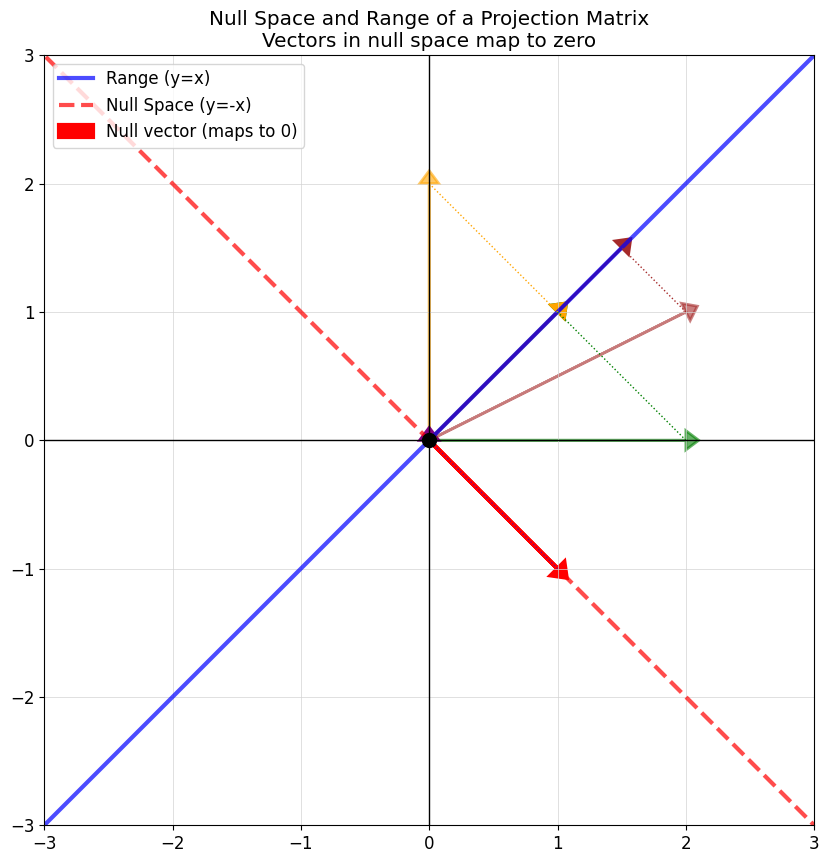


Null vector [1, -1] maps to: [0. 0.]


In [7]:
# Visualize null space for a 2D -> 1D projection
# This matrix projects onto a line
direction = np.array([1, 1]) / np.sqrt(2)
P = np.outer(direction, direction)  # Projection matrix

print("Projection matrix P (projects onto line y=x):")
print(P)

fig, ax = plt.subplots(figsize=(10, 10))

# Draw coordinate grid
for i in range(-3, 4):
    ax.axhline(y=i, color='lightgray', linewidth=0.5)
    ax.axvline(x=i, color='lightgray', linewidth=0.5)

# Draw the range (line y=x)
t = np.linspace(-4, 4, 100)
ax.plot(t, t, 'b-', linewidth=3, label='Range (y=x)', alpha=0.7)

# Draw the null space (line y=-x)
ax.plot(t, -t, 'r--', linewidth=3, label='Null Space (y=-x)', alpha=0.7)

# Show some vectors and their projections
test_vectors = [np.array([2, 0]), np.array([0, 2]), np.array([1, -1]), np.array([2, 1])]
colors = ['green', 'orange', 'purple', 'brown']

for v, c in zip(test_vectors, colors):
    Pv = P @ v
    ax.arrow(0, 0, v[0], v[1], head_width=0.15, head_length=0.1, 
             fc=c, ec=c, linewidth=2, alpha=0.6)
    ax.arrow(0, 0, Pv[0], Pv[1], head_width=0.15, head_length=0.1, 
             fc=c, ec=c, linewidth=2)
    ax.plot([v[0], Pv[0]], [v[1], Pv[1]], linestyle=':', color=c, linewidth=1)

# Null space vector example
null_v = np.array([1, -1])
ax.arrow(0, 0, null_v[0], null_v[1], head_width=0.15, head_length=0.1, 
         fc='red', ec='red', linewidth=3, label='Null vector (maps to 0)')
ax.plot(0, 0, 'ko', markersize=10)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.set_title('Null Space and Range of a Projection Matrix\nVectors in null space map to zero')
ax.legend(loc='upper left')
plt.show()

print(f"\nNull vector [1, -1] maps to: {P @ np.array([1, -1])}")

## 4. Projections

The **orthogonal projection** of vector $\mathbf{b}$ onto vector $\mathbf{a}$ is:

$$\text{proj}_{\mathbf{a}}\mathbf{b} = \frac{\mathbf{a} \cdot \mathbf{b}}{\mathbf{a} \cdot \mathbf{a}}\mathbf{a} = \frac{\mathbf{a}^T\mathbf{b}}{\mathbf{a}^T\mathbf{a}}\mathbf{a}$$

The projection matrix onto a subspace spanned by columns of $A$ is:

$$P = A(A^TA)^{-1}A^T$$

In [8]:
def project_onto_vector(b, a):
    """
    Project vector b onto vector a.
    """
    return (np.dot(a, b) / np.dot(a, a)) * a

def project_onto_subspace(b, A):
    """
    Project vector b onto the column space of matrix A.
    Uses the formula: P = A(A^T A)^{-1} A^T
    """
    P = A @ np.linalg.inv(A.T @ A) @ A.T
    return P @ b

# Example: Project onto a vector in 2D
a = np.array([3, 1])
b = np.array([1, 3])

proj = project_onto_vector(b, a)

print(f"Vector a: {a}")
print(f"Vector b: {b}")
print(f"Projection of b onto a: {proj}")
print(f"\nVerification: (b - proj) is orthogonal to a")
print(f"(b - proj) . a = {np.dot(b - proj, a):.10f}")

Vector a: [3 1]
Vector b: [1 3]
Projection of b onto a: [1.8 0.6]

Verification: (b - proj) is orthogonal to a
(b - proj) . a = 0.0000000000


In [9]:
def interactive_projection_2d(ax=3, ay=1, bx=1, by=3):
    """
    Interactive visualization of vector projection in 2D.
    """
    a = np.array([ax, ay])
    b = np.array([bx, by])
    
    # Compute projection
    proj = project_onto_vector(b, a)
    error = b - proj
    
    fig, ax_plot = plt.subplots(figsize=(10, 10))
    
    # Draw the line containing vector a
    t = np.linspace(-5, 5, 100)
    if np.linalg.norm(a) > 0:
        a_unit = a / np.linalg.norm(a)
        ax_plot.plot(t * a_unit[0], t * a_unit[1], 'b--', alpha=0.3, linewidth=2)
    
    # Vector a
    ax_plot.arrow(0, 0, a[0], a[1], head_width=0.15, head_length=0.1, 
                  fc='blue', ec='blue', linewidth=2, label=f'a = [{a[0]}, {a[1]}]')
    
    # Vector b
    ax_plot.arrow(0, 0, b[0], b[1], head_width=0.15, head_length=0.1, 
                  fc='green', ec='green', linewidth=2, label=f'b = [{b[0]}, {b[1]}]')
    
    # Projection
    ax_plot.arrow(0, 0, proj[0], proj[1], head_width=0.15, head_length=0.1, 
                  fc='red', ec='red', linewidth=2, label=f'proj = [{proj[0]:.2f}, {proj[1]:.2f}]')
    
    # Error vector (b - proj)
    ax_plot.arrow(proj[0], proj[1], error[0], error[1], head_width=0.1, head_length=0.08, 
                  fc='orange', ec='orange', linewidth=2, label='error (orthogonal)')
    
    # Right angle marker
    if np.linalg.norm(proj) > 0.5 and np.linalg.norm(error) > 0.5:
        size = 0.3
        a_unit = a / np.linalg.norm(a) if np.linalg.norm(a) > 0 else np.array([1, 0])
        e_unit = error / np.linalg.norm(error) if np.linalg.norm(error) > 0 else np.array([0, 1])
        corner = proj - size * a_unit
        square = np.array([corner, corner + size * e_unit, 
                          corner + size * e_unit - size * a_unit, corner - size * a_unit])
    
    ax_plot.set_xlim(-5, 5)
    ax_plot.set_ylim(-5, 5)
    ax_plot.axhline(y=0, color='k', linewidth=0.5)
    ax_plot.axvline(x=0, color='k', linewidth=0.5)
    ax_plot.grid(True, alpha=0.3)
    ax_plot.set_aspect('equal')
    ax_plot.set_title(f'Orthogonal Projection\n||error|| = {np.linalg.norm(error):.3f}')
    ax_plot.legend(loc='upper left')
    plt.show()

interact(interactive_projection_2d,
         ax=widgets.FloatSlider(min=-4, max=4, step=0.5, value=3, description='a_x'),
         ay=widgets.FloatSlider(min=-4, max=4, step=0.5, value=1, description='a_y'),
         bx=widgets.FloatSlider(min=-4, max=4, step=0.5, value=1, description='b_x'),
         by=widgets.FloatSlider(min=-4, max=4, step=0.5, value=3, description='b_y'));

interactive(children=(FloatSlider(value=3.0, description='a_x', max=4.0, min=-4.0, step=0.5), FloatSlider(valu…

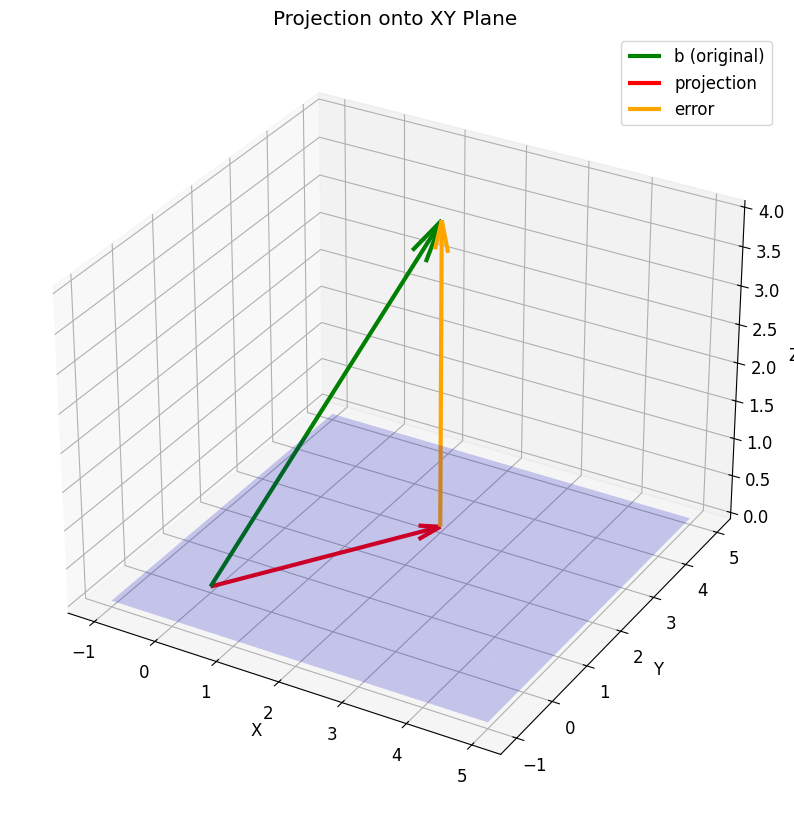

Original vector b: [2 3 4]
Projection onto plane: [2. 3. 0.]
Error (perpendicular): [0. 0. 4.]


In [10]:
# Projection onto a plane in 3D
def visualize_projection_3d():
    """
    Visualize projection of a vector onto a plane in 3D.
    """
    # Define plane by two vectors
    v1 = np.array([1, 0, 0])
    v2 = np.array([0, 1, 0])
    A = np.column_stack([v1, v2])
    
    # Vector to project
    b = np.array([2, 3, 4])
    
    # Compute projection
    proj = project_onto_subspace(b, A)
    
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Draw the plane (z=0 plane)
    xx, yy = np.meshgrid(np.linspace(-1, 5, 10), np.linspace(-1, 5, 10))
    zz = np.zeros_like(xx)
    ax.plot_surface(xx, yy, zz, alpha=0.2, color='blue')
    
    # Original vector
    ax.quiver(0, 0, 0, b[0], b[1], b[2], color='green', linewidth=3, 
              arrow_length_ratio=0.1, label='b (original)')
    
    # Projection
    ax.quiver(0, 0, 0, proj[0], proj[1], proj[2], color='red', linewidth=3,
              arrow_length_ratio=0.1, label='projection')
    
    # Error (perpendicular to plane)
    error = b - proj
    ax.quiver(proj[0], proj[1], proj[2], error[0], error[1], error[2], 
              color='orange', linewidth=3, arrow_length_ratio=0.1, label='error')
    
    # Dotted line from b to projection
    ax.plot([b[0], proj[0]], [b[1], proj[1]], [b[2], proj[2]], 'k--', alpha=0.5)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Projection onto XY Plane')
    ax.legend()
    
    plt.show()
    
    print(f"Original vector b: {b}")
    print(f"Projection onto plane: {proj}")
    print(f"Error (perpendicular): {b - proj}")

visualize_projection_3d()

## 5. Gram-Schmidt Orthogonalization

The **Gram-Schmidt process** takes a set of linearly independent vectors and produces an orthonormal basis.

Given vectors $\{\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_k\}$:

1. $\mathbf{u}_1 = \mathbf{v}_1$
2. $\mathbf{u}_2 = \mathbf{v}_2 - \text{proj}_{\mathbf{u}_1}\mathbf{v}_2$
3. $\mathbf{u}_k = \mathbf{v}_k - \sum_{j=1}^{k-1}\text{proj}_{\mathbf{u}_j}\mathbf{v}_k$

Then normalize: $\mathbf{e}_i = \mathbf{u}_i / \|\mathbf{u}_i\|$

In [11]:
def gram_schmidt(vectors, verbose=False):
    """
    Perform Gram-Schmidt orthogonalization.
    
    Parameters:
        vectors: list of numpy arrays (linearly independent vectors)
        verbose: if True, print intermediate steps
    
    Returns:
        orthonormal: list of orthonormal vectors
        orthogonal: list of orthogonal vectors (before normalization)
    """
    orthogonal = []
    
    for i, v in enumerate(vectors):
        # Start with the original vector
        u = v.copy().astype(float)
        
        # Subtract projections onto all previous orthogonal vectors
        for j, u_prev in enumerate(orthogonal):
            proj = project_onto_vector(v, u_prev)
            u = u - proj
            if verbose:
                print(f"  Subtract proj onto u{j+1}: {proj}")
        
        orthogonal.append(u)
        if verbose:
            print(f"u{i+1} = {u}")
            print()
    
    # Normalize
    orthonormal = [u / np.linalg.norm(u) for u in orthogonal]
    
    return orthonormal, orthogonal

# Example
v1 = np.array([1, 1, 0])
v2 = np.array([1, 0, 1])
v3 = np.array([0, 1, 1])

print("Original vectors:")
print(f"v1 = {v1}")
print(f"v2 = {v2}")
print(f"v3 = {v3}")
print("\nGram-Schmidt process:")
print("="*50)

orthonormal, orthogonal = gram_schmidt([v1, v2, v3], verbose=True)

print("Orthonormal basis:")
for i, e in enumerate(orthonormal):
    print(f"e{i+1} = {e}")

Original vectors:
v1 = [1 1 0]
v2 = [1 0 1]
v3 = [0 1 1]

Gram-Schmidt process:
u1 = [1. 1. 0.]

  Subtract proj onto u1: [0.5 0.5 0. ]
u2 = [ 0.5 -0.5  1. ]

  Subtract proj onto u1: [0.5 0.5 0. ]
  Subtract proj onto u2: [ 0.16666667 -0.16666667  0.33333333]
u3 = [-0.66666667  0.66666667  0.66666667]

Orthonormal basis:
e1 = [0.70710678 0.70710678 0.        ]
e2 = [ 0.40824829 -0.40824829  0.81649658]
e3 = [-0.57735027  0.57735027  0.57735027]


In [12]:
# Verify orthonormality
print("Verification:")
print("\nDot products (should be 0 for i != j, 1 for i == j):")
for i in range(len(orthonormal)):
    for j in range(len(orthonormal)):
        dot = np.dot(orthonormal[i], orthonormal[j])
        print(f"  e{i+1} . e{j+1} = {dot:.6f}")

print("\nNorms (should all be 1):")
for i, e in enumerate(orthonormal):
    print(f"  ||e{i+1}|| = {np.linalg.norm(e):.6f}")

Verification:

Dot products (should be 0 for i != j, 1 for i == j):
  e1 . e1 = 1.000000
  e1 . e2 = 0.000000
  e1 . e3 = 0.000000
  e2 . e1 = 0.000000
  e2 . e2 = 1.000000
  e2 . e3 = 0.000000
  e3 . e1 = 0.000000
  e3 . e2 = 0.000000
  e3 . e3 = 1.000000

Norms (should all be 1):
  ||e1|| = 1.000000
  ||e2|| = 1.000000
  ||e3|| = 1.000000


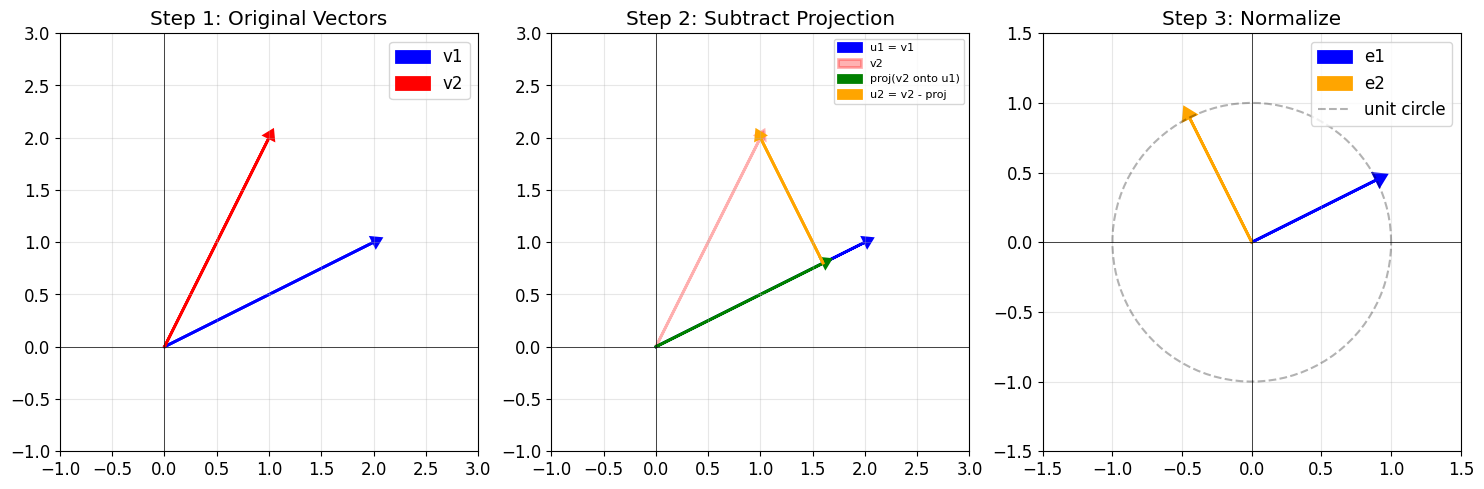

e1 . e2 = -0.000000 (orthogonal)


In [13]:
# Visualize Gram-Schmidt in 2D
v1_2d = np.array([2, 1])
v2_2d = np.array([1, 2])

orthonormal_2d, orthogonal_2d = gram_schmidt([v1_2d, v2_2d])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Step 1: Original vectors
ax = axes[0]
ax.arrow(0, 0, v1_2d[0], v1_2d[1], head_width=0.1, head_length=0.08, 
         fc='blue', ec='blue', linewidth=2, label='v1')
ax.arrow(0, 0, v2_2d[0], v2_2d[1], head_width=0.1, head_length=0.08, 
         fc='red', ec='red', linewidth=2, label='v2')
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Step 1: Original Vectors')
ax.legend()

# Step 2: First orthogonal vector and projection
ax = axes[1]
u1 = orthogonal_2d[0]
proj = project_onto_vector(v2_2d, u1)
u2 = orthogonal_2d[1]

ax.arrow(0, 0, u1[0], u1[1], head_width=0.1, head_length=0.08, 
         fc='blue', ec='blue', linewidth=2, label='u1 = v1')
ax.arrow(0, 0, v2_2d[0], v2_2d[1], head_width=0.1, head_length=0.08, 
         fc='red', ec='red', linewidth=2, alpha=0.3, label='v2')
ax.arrow(0, 0, proj[0], proj[1], head_width=0.1, head_length=0.08, 
         fc='green', ec='green', linewidth=2, label='proj(v2 onto u1)')
ax.arrow(proj[0], proj[1], u2[0], u2[1], head_width=0.1, head_length=0.08, 
         fc='orange', ec='orange', linewidth=2, label='u2 = v2 - proj')

ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Step 2: Subtract Projection')
ax.legend(fontsize=8)

# Step 3: Orthonormal vectors
ax = axes[2]
e1 = orthonormal_2d[0]
e2 = orthonormal_2d[1]

ax.arrow(0, 0, e1[0], e1[1], head_width=0.1, head_length=0.08, 
         fc='blue', ec='blue', linewidth=2, label='e1')
ax.arrow(0, 0, e2[0], e2[1], head_width=0.1, head_length=0.08, 
         fc='orange', ec='orange', linewidth=2, label='e2')

# Draw unit circle
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, label='unit circle')

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Step 3: Normalize')
ax.legend()

plt.tight_layout()
plt.show()

print(f"e1 . e2 = {np.dot(e1, e2):.6f} (orthogonal)")

## 6. Least Squares as Projection

Linear regression can be understood as **projecting the target vector onto the column space** of the design matrix.

Given $A\mathbf{x} = \mathbf{b}$ with no exact solution, we find $\hat{\mathbf{x}}$ that minimizes $\|A\mathbf{x} - \mathbf{b}\|$.

The solution is:
$$\hat{\mathbf{x}} = (A^TA)^{-1}A^T\mathbf{b}$$

And $A\hat{\mathbf{x}}$ is the projection of $\mathbf{b}$ onto the column space of $A$.

In [14]:
# Generate data for linear regression
np.random.seed(42)
n_points = 50
x = np.linspace(0, 10, n_points)
true_slope = 2
true_intercept = 1
noise = np.random.randn(n_points) * 2
y = true_slope * x + true_intercept + noise

# Design matrix (with column of ones for intercept)
A = np.column_stack([np.ones(n_points), x])

print("Design matrix A shape:", A.shape)
print("First 5 rows of A:")
print(A[:5])

# Solve using normal equations
x_hat = np.linalg.inv(A.T @ A) @ A.T @ y
print(f"\nLeast squares solution: intercept={x_hat[0]:.3f}, slope={x_hat[1]:.3f}")
print(f"True values: intercept={true_intercept}, slope={true_slope}")

Design matrix A shape: (50, 2)
First 5 rows of A:
[[1.         0.        ]
 [1.         0.20408163]
 [1.         0.40816327]
 [1.         0.6122449 ]
 [1.         0.81632653]]

Least squares solution: intercept=1.129, slope=1.884
True values: intercept=1, slope=2


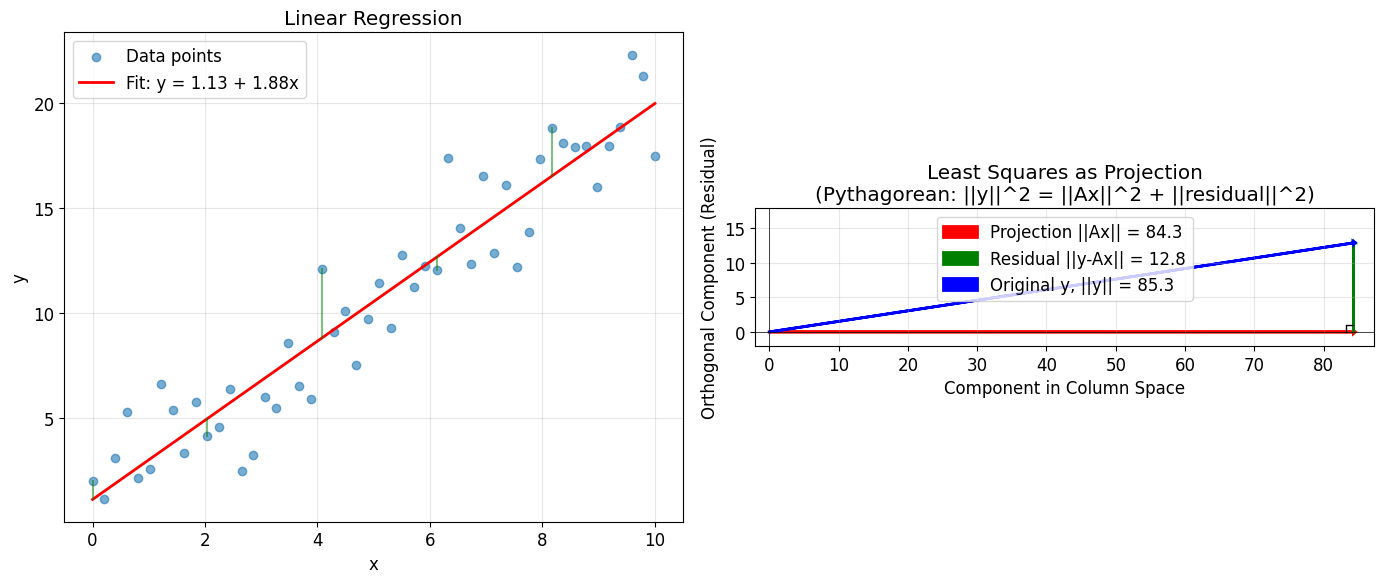


Verifying Pythagorean theorem:
||y||^2 = 7268.51
||Ax||^2 + ||residual||^2 = 7103.48 + 165.03 = 7268.51


In [15]:
# Visualize least squares as projection
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Standard regression plot
ax = axes[0]
ax.scatter(x, y, alpha=0.6, label='Data points')
x_line = np.linspace(0, 10, 100)
y_line = x_hat[0] + x_hat[1] * x_line
ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'Fit: y = {x_hat[0]:.2f} + {x_hat[1]:.2f}x')

# Show residuals for a few points
y_pred = A @ x_hat
for i in range(0, n_points, 10):
    ax.plot([x[i], x[i]], [y[i], y_pred[i]], 'g-', alpha=0.5)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Linear Regression')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Projection interpretation
ax = axes[1]

# In this high-dimensional view, y is a vector, and we project it
# onto the column space of A
residual = y - y_pred
residual_norm = np.linalg.norm(residual)
y_norm = np.linalg.norm(y)
proj_norm = np.linalg.norm(y_pred)

# Create a 2D representation
# Think of it as: y has component in column space (y_pred) and orthogonal (residual)
ax.arrow(0, 0, proj_norm, 0, head_width=0.5, head_length=0.3, 
         fc='red', ec='red', linewidth=2, label=f'Projection ||Ax|| = {proj_norm:.1f}')
ax.arrow(proj_norm, 0, 0, residual_norm, head_width=0.5, head_length=0.3, 
         fc='green', ec='green', linewidth=2, label=f'Residual ||y-Ax|| = {residual_norm:.1f}')
ax.arrow(0, 0, proj_norm, residual_norm, head_width=0.5, head_length=0.3, 
         fc='blue', ec='blue', linewidth=2, label=f'Original y, ||y|| = {y_norm:.1f}')

# Right angle marker
ax.plot([proj_norm-1, proj_norm-1, proj_norm], [0, 1, 1], 'k-', linewidth=1)

ax.set_xlim(-2, y_norm + 2)
ax.set_ylim(-2, residual_norm + 5)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('Component in Column Space')
ax.set_ylabel('Orthogonal Component (Residual)')
ax.set_title('Least Squares as Projection\n(Pythagorean: ||y||^2 = ||Ax||^2 + ||residual||^2)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verify Pythagorean theorem
print(f"\nVerifying Pythagorean theorem:")
print(f"||y||^2 = {y_norm**2:.2f}")
print(f"||Ax||^2 + ||residual||^2 = {proj_norm**2:.2f} + {residual_norm**2:.2f} = {proj_norm**2 + residual_norm**2:.2f}")

## 7. Word Embedding Arithmetic

Word embeddings map words to vectors in a learned vector space where semantic relationships become geometric relationships.

The famous example: **king - man + woman = queen**

This works because the "gender" direction in the embedding space is consistent across related word pairs.

In [16]:
# Simulated word embeddings (in practice, these come from Word2Vec, GloVe, etc.)
# We'll create simplified 3D embeddings that demonstrate the concept
np.random.seed(42)

# Define embedding dimensions:
# dim 0: royalty
# dim 1: gender (male -> positive, female -> negative)
# dim 2: age

embeddings = {
    'king':   np.array([0.9, 0.8, 0.5]),
    'queen':  np.array([0.9, -0.8, 0.5]),
    'man':    np.array([0.1, 0.7, 0.5]),
    'woman':  np.array([0.1, -0.7, 0.5]),
    'prince': np.array([0.8, 0.7, -0.5]),
    'princess': np.array([0.8, -0.7, -0.5]),
    'boy':    np.array([0.0, 0.6, -0.7]),
    'girl':   np.array([0.0, -0.6, -0.7]),
    'father': np.array([0.2, 0.8, 0.7]),
    'mother': np.array([0.2, -0.8, 0.7]),
}

def find_closest_word(target_vector, embeddings, exclude=None):
    """
    Find the word whose embedding is closest to the target vector.
    """
    if exclude is None:
        exclude = []
    
    best_word = None
    best_similarity = -np.inf
    
    for word, vec in embeddings.items():
        if word in exclude:
            continue
        # Cosine similarity
        similarity = np.dot(target_vector, vec) / (np.linalg.norm(target_vector) * np.linalg.norm(vec))
        if similarity > best_similarity:
            best_similarity = similarity
            best_word = word
    
    return best_word, best_similarity

def word_analogy(a, b, c, embeddings):
    """
    Solve: a is to b as c is to ?
    Formula: ? = b - a + c
    """
    target = embeddings[b] - embeddings[a] + embeddings[c]
    result, similarity = find_closest_word(target, embeddings, exclude=[a, b, c])
    return result, similarity, target

# Test the famous analogy
print("Word Embedding Analogies")
print("="*50)

analogies = [
    ('man', 'king', 'woman'),      # man:king :: woman:?
    ('man', 'boy', 'woman'),       # man:boy :: woman:?
    ('king', 'prince', 'queen'),   # king:prince :: queen:?
    ('father', 'mother', 'boy'),   # father:mother :: boy:?
]

for a, b, c in analogies:
    result, sim, _ = word_analogy(a, b, c, embeddings)
    print(f"{a} : {b} :: {c} : {result}  (similarity: {sim:.3f})")

Word Embedding Analogies
man : king :: woman : queen  (similarity: 0.991)
man : boy :: woman : girl  (similarity: 0.990)
king : prince :: queen : princess  (similarity: 0.992)
father : mother :: boy : girl  (similarity: 0.969)


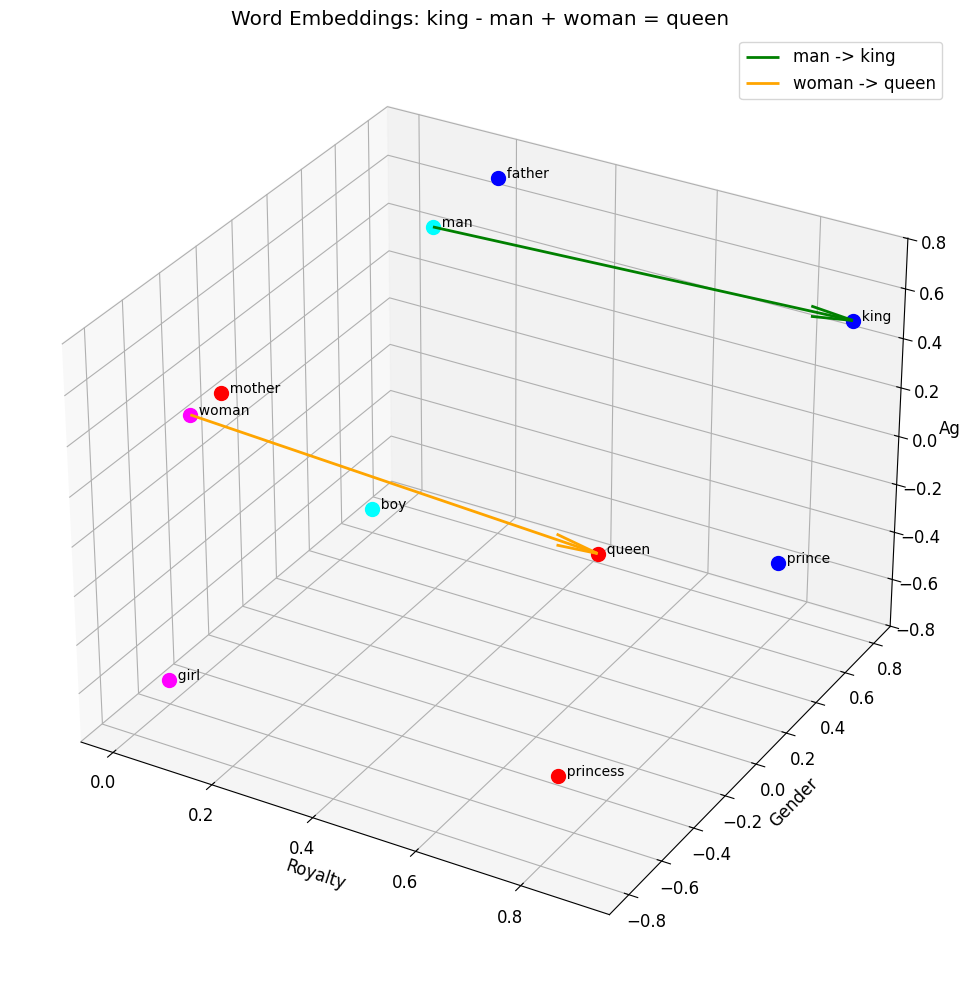


Vector Arithmetic:
king  = [0.9 0.8 0.5]
man   = [0.1 0.7 0.5]
woman = [ 0.1 -0.7  0.5]
king - man + woman = [ 0.9 -0.6  0.5]
queen = [ 0.9 -0.8  0.5]


In [17]:
# Visualize word embeddings in 3D
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot all words
colors = {'king': 'blue', 'queen': 'red', 'man': 'cyan', 'woman': 'magenta',
          'prince': 'blue', 'princess': 'red', 'boy': 'cyan', 'girl': 'magenta',
          'father': 'blue', 'mother': 'red'}

for word, vec in embeddings.items():
    ax.scatter(vec[0], vec[1], vec[2], c=colors[word], s=100)
    ax.text(vec[0], vec[1], vec[2], f'  {word}', fontsize=10)

# Draw the analogy vectors
king = embeddings['king']
man = embeddings['man']
woman = embeddings['woman']
queen = embeddings['queen']

# man -> king (what we add)
ax.quiver(man[0], man[1], man[2], 
          king[0]-man[0], king[1]-man[1], king[2]-man[2],
          color='green', linewidth=2, arrow_length_ratio=0.1, label='man -> king')

# woman -> queen (parallel relationship)
ax.quiver(woman[0], woman[1], woman[2], 
          queen[0]-woman[0], queen[1]-woman[1], queen[2]-woman[2],
          color='orange', linewidth=2, arrow_length_ratio=0.1, label='woman -> queen')

ax.set_xlabel('Royalty')
ax.set_ylabel('Gender')
ax.set_zlabel('Age')
ax.set_title('Word Embeddings: king - man + woman = queen')
ax.legend()

plt.tight_layout()
plt.show()

# Show the arithmetic
print("\nVector Arithmetic:")
print(f"king  = {embeddings['king']}")
print(f"man   = {embeddings['man']}")
print(f"woman = {embeddings['woman']}")
print(f"king - man + woman = {embeddings['king'] - embeddings['man'] + embeddings['woman']}")
print(f"queen = {embeddings['queen']}")

In [18]:
# Analyze the "gender" direction in embedding space
# This direction should be consistent across word pairs

gender_pairs = [
    ('man', 'woman'),
    ('king', 'queen'),
    ('boy', 'girl'),
    ('father', 'mother'),
    ('prince', 'princess'),
]

print("Gender direction vectors (male - female):")
print("="*50)

gender_vectors = []
for male, female in gender_pairs:
    diff = embeddings[male] - embeddings[female]
    gender_vectors.append(diff)
    print(f"{male:8s} - {female:8s} = {diff}")

# Compute average gender direction
avg_gender = np.mean(gender_vectors, axis=0)
print(f"\nAverage gender direction: {avg_gender}")
print("\nNote: Dimension 1 (gender) dominates, as expected.")

# Check consistency using cosine similarity
print("\nConsistency of gender direction (cosine similarity with average):")
for i, ((male, female), vec) in enumerate(zip(gender_pairs, gender_vectors)):
    cos_sim = np.dot(vec, avg_gender) / (np.linalg.norm(vec) * np.linalg.norm(avg_gender))
    print(f"  {male}-{female}: {cos_sim:.4f}")

Gender direction vectors (male - female):
man      - woman    = [0.  1.4 0. ]
king     - queen    = [0.  1.6 0. ]
boy      - girl     = [0.  1.2 0. ]
father   - mother   = [0.  1.6 0. ]
prince   - princess = [0.  1.4 0. ]

Average gender direction: [0.   1.44 0.  ]

Note: Dimension 1 (gender) dominates, as expected.

Consistency of gender direction (cosine similarity with average):
  man-woman: 1.0000
  king-queen: 1.0000
  boy-girl: 1.0000
  father-mother: 1.0000
  prince-princess: 1.0000


## Summary: Connections to Modern ML

The vector space concepts we've explored are fundamental to modern machine learning:

### Embeddings
- **Word embeddings** (Word2Vec, GloVe, BERT) represent words as vectors where semantic similarity becomes geometric proximity
- **Image embeddings** from CNNs capture visual features in high-dimensional vector spaces
- **Learned representations** in any neural network can be viewed as mappings to vector spaces

### Attention Mechanisms
- In transformers, **attention** computes weighted combinations of value vectors
- This is fundamentally a **projection** operation in the embedding space
- Query-key similarity determines the weights for the linear combination

### LoRA (Low-Rank Adaptation)
- Fine-tunes large models by adding **low-rank** update matrices: $W' = W + BA$
- Instead of updating all $d \times d$ parameters, we learn $B$ (d x r) and $A$ (r x d) where $r << d$
- This works because weight updates often lie in a **low-dimensional subspace**

### Key Takeaways
1. **Basis and span** help us understand what directions a set of embeddings can represent
2. **Linear independence** ensures our representations aren't redundant
3. **Projections** are the core operation in attention and many other architectures
4. **Orthogonalization** (Gram-Schmidt) underlies techniques like QR decomposition used in optimization
5. **Least squares** connects linear algebra to the loss functions we minimize

---

*Continue to Chapter 11 for gradient descent optimization...*